## Preparation

### Libraries import & metadata storage definitions

In [ ]:
import os
import sys
import numpy as np

import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.decomposition import TruncatedSVD
from scipy import stats
from scipy.special import softmax

In [2]:
sys.path.append('../common_key_functions')
from all_plots import plot_heatmap, plot_colored_barplot
from helpful_funcs import calc_ljust_spaces, pretty_print_top1_top5_time

In [3]:
checkpoint_dir = "checkpoints_imagenet"
graph_dir = "graphs_imagenet"
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(graph_dir, exist_ok=True)

In [4]:
figsize_squared = (30, 7)
figsize_long = (3, 15)

## Dataset download & instantiation

### ImageNet-1K

В работе рассматривается задача классификации изображений, для которой используются модель [семейства RegNet](https://docs.pytorch.org/vision/main/models/regnet.html) версии RegNet_X_3_2_GF и датасет [ImageNet-1K (ILSVRC2017)](https://www.kaggle.com/competitions/imagenet-object-localization-challenge/overview). 

Датасет ImageNet содержит высокого (различного) разрешения, каждое из которых аннотировано с использованием синсетов WordNet и соотносится с 1 или более из 1000 классов; классы не сбалансированы. Подсеты имеют следующую мощность:
- train - 1,3 млн изображений,
- val - 50 тыс изображений,
- test - 100 тыс изображений.

Модель для ускорения обучения инициализируется весами, предобученными на датасете ImageNet со следующими метриками точности:
- acc1: 78.364,
- acc5: 93.992

без дообучения.

In [5]:
def make_val_loader_imagenet(val_dir: str, 
                             batch_size: int | None  = 256, 
                             num_workers: int | None  = 4,
                             picture_size: int | None  = 224):
    transforms_val = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(picture_size),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        ),
    ])

    imagenet_val = datasets.ImageNet(
        root=val_dir, 
        split="val", 
        transform=transforms_val
    )

    return DataLoader(
        imagenet_val, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=num_workers, 
        pin_memory=True
    )

In [6]:
dataset_dir_imagenet = "/media/user/Hitachi/ILSVRC/Data/CLS-LOC"
dataset_name = "ImageNet"
picture_size = 224

n_classes = 1000
batch_size = 32
num_workers = 4

In [7]:
print(f"[ ] Creating dataset {dataset_name}...")
val_loader = make_val_loader_imagenet(dataset_dir_imagenet, batch_size, num_workers)
classes_names = val_loader.dataset.classes  # type: ignore
print(f"[V] Dataset {dataset_name} created")

[ ] Creating dataset ImageNet...
[V] Dataset ImageNet created


## Model preparation

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name() if device.type == "cuda" else device.type)

Device: NVIDIA GeForce GTX 1650


### RegNetX_3_2 download & instantiation

In [ ]:
print("[ ] Instantiating model...")
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
regnetx_3_2.to(device)
regnetx_3_2_name = "RegNetX_3_2"
print(f"[V] {regnetx_3_2_name} with default weights instantiated")

[ ] Instantiating model...
[V] RegNetX_3_2 with default weights instantiated


## Main pipeline

### Pipeline: validation, binarization, weights fuse

In [10]:
avgpool_input_float, avgpool_input_bin, avgpool_input_bin_values = [], [], []
scale_bin_coeff = 6   # scaling coefficient for binarization hook from 'ADD-ONs: Binarizarion function choice'

def binarize_hook(module, input):
    x, = input
    x_bin = 2 ** ((x+1).log2().mul(1/scale_bin_coeff).round().mul(scale_bin_coeff)) - 1
    
    global avgpool_input_float, avgpool_input_bin, avgpool_input_bin_values
    avgpool_input_float = x
    avgpool_input_bin = x_bin
    avgpool_input_bin_values = x_bin.unique()
    
    return (x_bin,)

In [ ]:
# print("\nValidating model before binarizing:")
# top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
#     regnetx_3_2, val_loader
# )

In [ ]:
print("\n2. Binarizing input of avgpool layer...\n")
regnetx_3_2.avgpool.register_forward_pre_hook(binarize_hook)

# print("\n[ ] Validating model after binarizing avgpool input:")
# top1_bin, top5_bin, val_time, _, _ = pretty_print_top1_top5_time(
#     regnetx_3_2, val_loader, 
#     top1_orig=top1_orig, 
#     top5_orig=top5_orig
# )


2. Binarizing input of avgpool layer...



In [13]:
# print("Binary values of last layer input:")  # in case the network was validated
# avgpool_input_bin_values

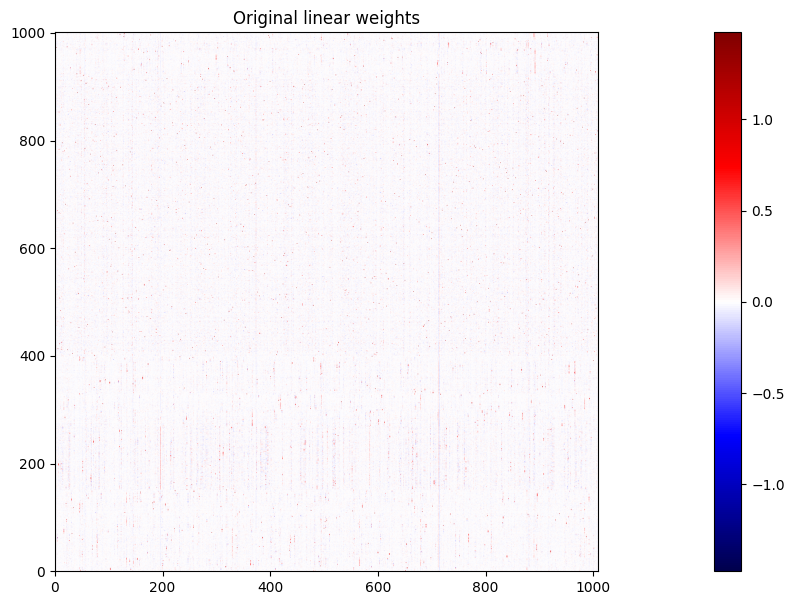

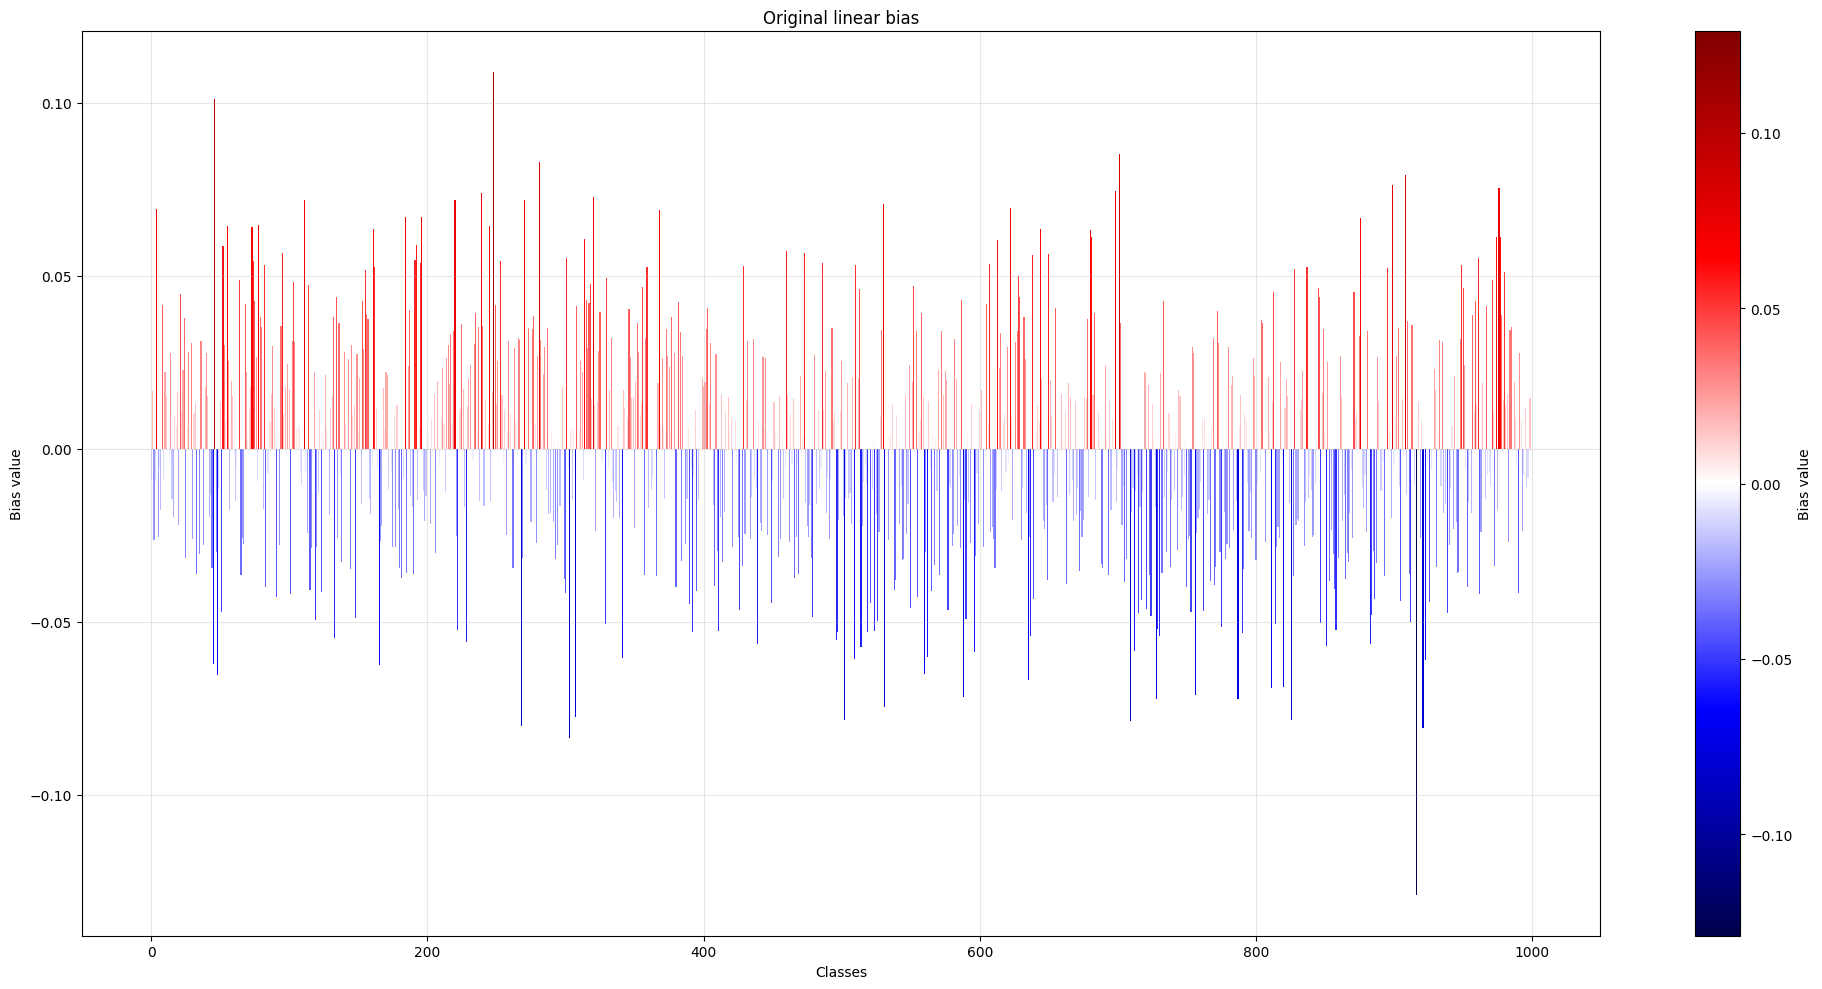

In [46]:
weights_orig = regnetx_3_2.fc.weight.data.cpu().numpy()
bias_orig = regnetx_3_2.fc.bias.detach().cpu().numpy()

plot_heatmap(
    weights_orig, 
    figsize=figsize_squared, 
    title="Original linear weights"
)
plot_colored_barplot(
    values=bias_orig,
    values_color=bias_orig,
    values_color_name="Bias value",
    title="Original linear bias",
    xlabel="Classes",
    ylabel="Bias value",
    edge_color=None,
    figsize=(20,10)
)

### SVD details analysis

In [15]:
seed = 42
torch.manual_seed(seed)

n_svd_components = min(weights_orig.shape)

print("\n4. Full SVD of centered linear layer...\n")
svd = TruncatedSVD(
    n_components=n_svd_components, 
    algorithm="randomized",
    # tol=0,
    random_state=seed
)
weights_reduced = svd.fit_transform(weights_orig)    #  X * V^T
print("    Explained variance ratio:", svd.explained_variance_ratio_.sum())


4. Full SVD of centered linear layer...

    Explained variance ratio: 1.0


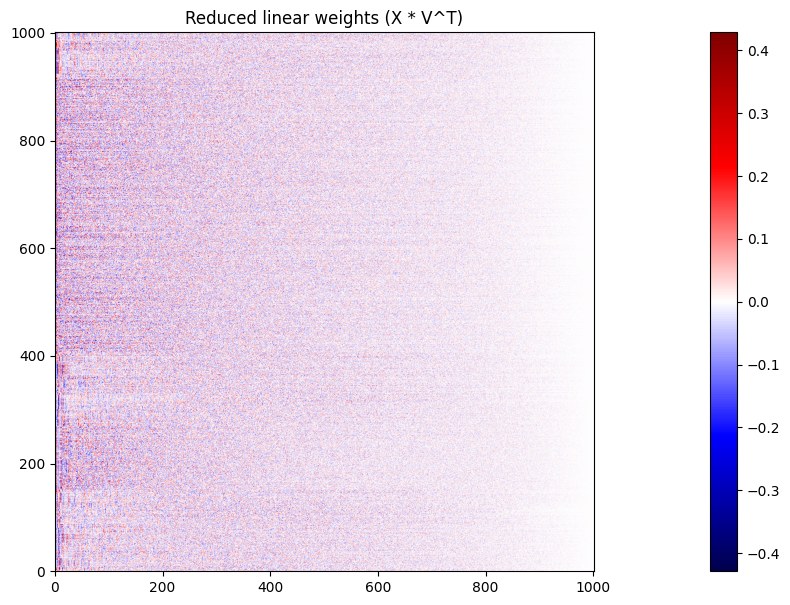

In [16]:
plot_heatmap(
    weights_reduced, 
    figsize=figsize_squared, 
    title="Reduced linear weights (X * V^T)"
)

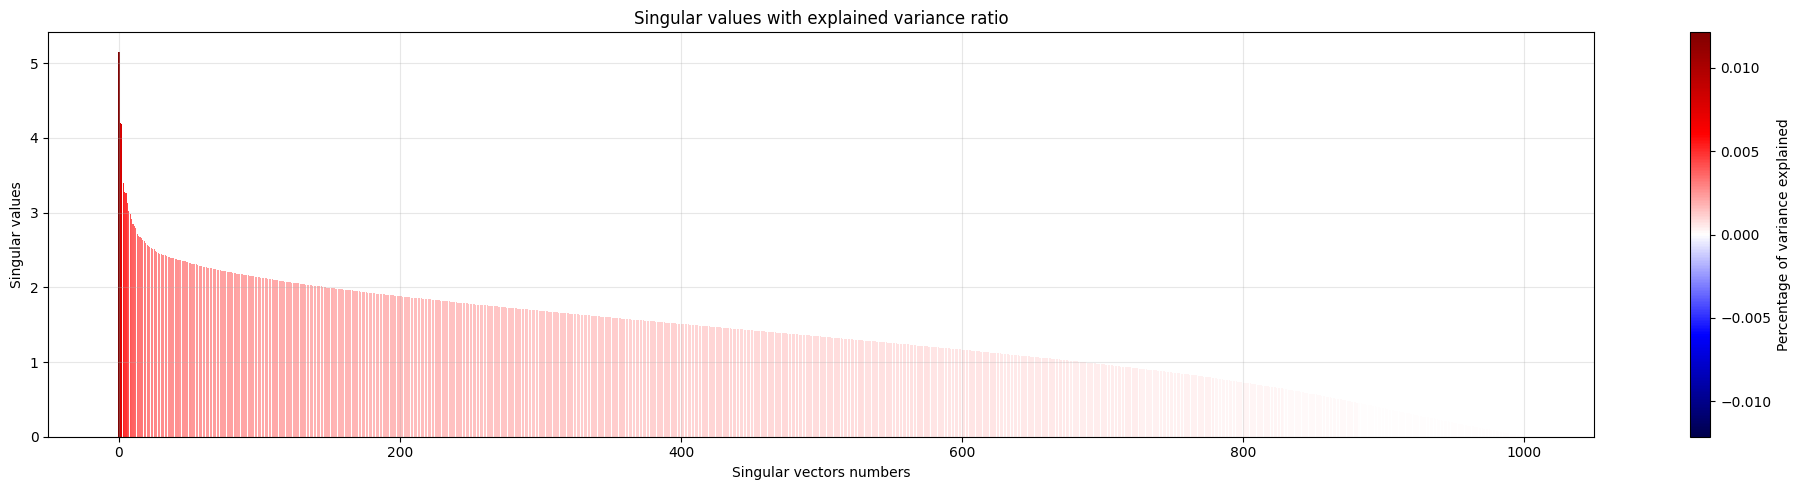

In [ ]:
sing_values = svd.singular_values_
expl_var_ratio = svd.explained_variance_ratio_

plot_colored_barplot(
    values=sing_values,
    values_color=expl_var_ratio,
    values_color_name="Percentage of variance explained",
    title="Singular values with explained variance ratio",
    xlabel="Singular vectors numbers",
    ylabel="Singular values",
    edge_color=None,
    figsize=(20,5)
)

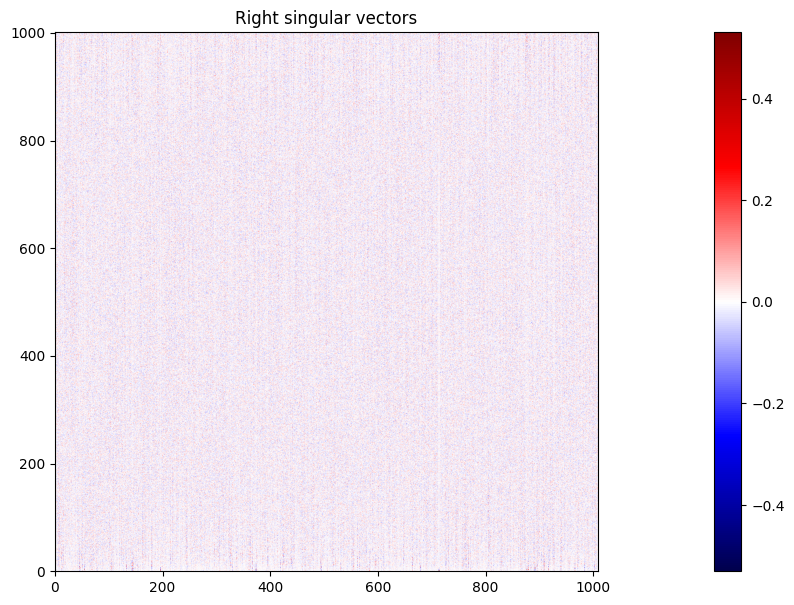

In [18]:
right_sing_vecs = svd.components_.T  # [n_svd_components, D features len]

plot_heatmap(
    np.transpose(right_sing_vecs), 
    figsize=figsize_squared,
    title="Right singular vectors"
)

In [ ]:
print("Top-10 singular values:                ", sing_values[:10])
print("Top-10 (according) explained variences:", expl_var_ratio[:10])

Top-10 singular values:                 [5.156461  4.2006392 4.181054  3.3935738 3.2799003 3.2579453 3.1297266
 3.021806  2.985043  2.908475 ]
Top-10 (according) explained variences: [0.01213396 0.00805249 0.00797759 0.00525551 0.00490932 0.00484382
 0.00447005 0.0041671  0.00406632 0.00386039]


### Weights decorrelation - SVD-whitening

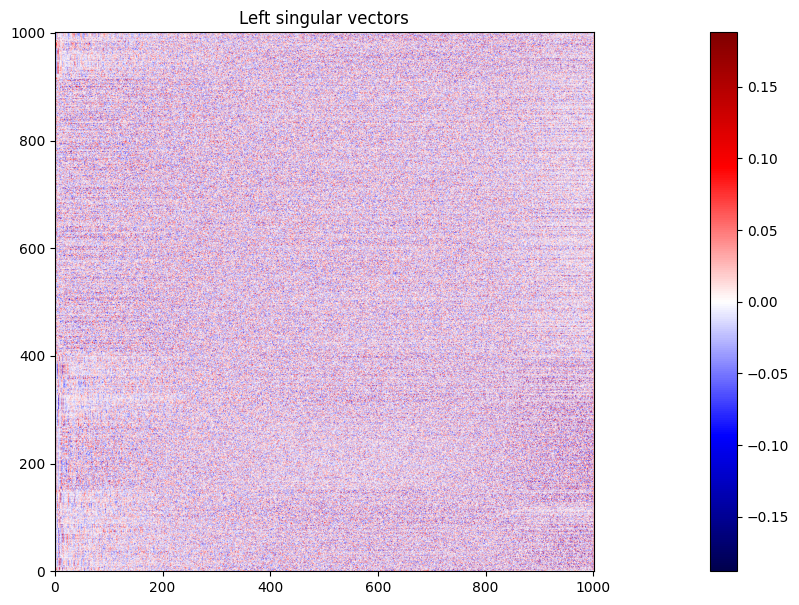

In [20]:
left_sing_vecs = weights_reduced @ ( np.diag(1 / svd.singular_values_) )  # [n_svd_components, D features len]

plot_heatmap(
    left_sing_vecs, 
    figsize=figsize_squared,
    title="Left singular vectors"
)

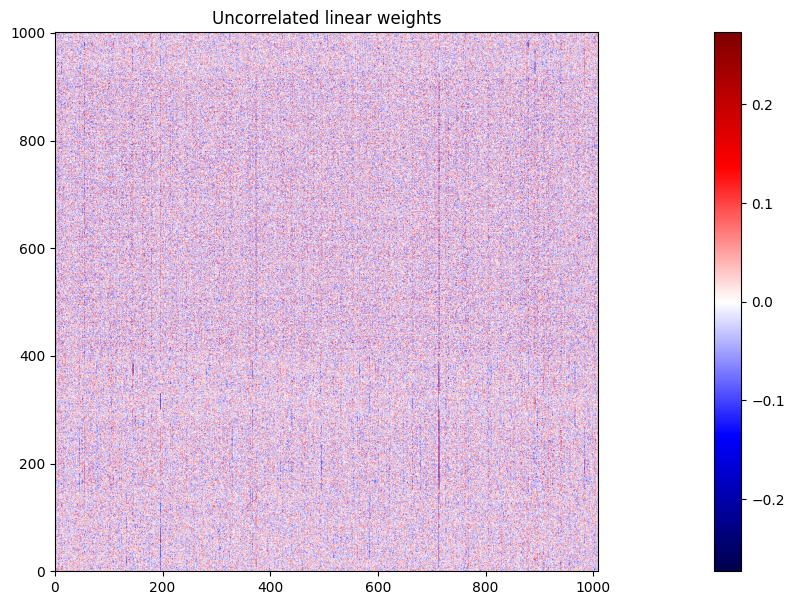

In [ ]:
left_sing_vecs_uncorr, _ = np.linalg.qr(left_sing_vecs)
weights_uncorr = left_sing_vecs_uncorr @ \
                 np.diag(sing_values) @ \
                 right_sing_vecs.T

plot_heatmap(
    weights_uncorr, 
    figsize=figsize_squared, 
    title="Uncorrelated linear weights"
)

### Significant features count as: singular vectors, reduced features, reconstructed features

In [22]:
def signific_features_count(weights,
                            signific_thresholds: list,
                            weights_name: str | None  = "",
                            is_strict: bool | None  = False,
                            is_return: bool | None  = False):
    signific_features_percent = {}
    thresholds_str, max_threshold_len = calc_ljust_spaces(signific_thresholds)
    
    signific_features_ns =  [ 
        np.sum(np.abs(weights) > threshold) 
        for threshold in signific_thresholds 
    ] if is_strict else [ 
        np.sum(np.abs(weights) >= threshold) 
        for threshold in signific_thresholds 
    ]

    print(f"    Percent of significant {weights_name} features:")
    sign = ">" if is_strict else ">="
    for i in range(len(signific_thresholds)):
        part = signific_features_ns[i] / weights.size
        print(
            f"        {sign} {thresholds_str[i].ljust(max_threshold_len)}: ", 
            f"{part:.5%}"        
        )
        signific_features_percent[thresholds_str[i]] = part * 100
    print("    of all features after SVD")
    
    return signific_features_percent \
           if is_return else None

In [23]:
print("\n6.1 Counting significant singular feature elements...\n")

signific_sing_thresholds = [0.01, 0.015, 0.02, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75]
signific_features_count(right_sing_vecs, signific_sing_thresholds, "singular")


6.1 Counting significant singular feature elements...

    Percent of significant singular features:
        >= 0.01 :  73.60744%
        >= 0.015:  61.38760%
        >= 0.02 :  50.37827%
        >= 0.025:  40.61657%
        >= 0.05 :  10.93641%
        >= 0.075:  2.15040%
        >= 0.1  :  0.35516%
        >= 0.15 :  0.01796%
        >= 0.2  :  0.00427%
        >= 0.25 :  0.00149%
        >= 0.5  :  0.00020%
        >= 0.75 :  0.00000%
    of all features after SVD


In [24]:
print("\n6.2 Counting significant reduced featuree elements...\n")

signific_red_thresholds = [0.01, 0.015, 0.02, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.5]
signific_features_count(weights_reduced, signific_red_thresholds, "reduced")


6.2 Counting significant reduced featuree elements...

    Percent of significant reduced features:
        >= 0.01 :  72.32260%
        >= 0.015:  62.82180%
        >= 0.02 :  54.59760%
        >= 0.025:  47.41480%
        >= 0.05 :  22.61430%
        >= 0.075:  10.41930%
        >= 0.1  :  4.68510%
        >= 0.15 :  0.99600%
        >= 0.2  :  0.25760%
        >= 0.25 :  0.07520%
        >= 0.5  :  0.00000%
    of all features after SVD


In [25]:
print("\n6.3 Counting significant uncorrelated featuree elements...\n")

signific_rec_thresholds = [0.001, 0.0015, 0.002, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.05, 0.1]
signific_features_count(
    weights_uncorr, 
    signific_rec_thresholds, 
    "(binary in perspective) reconstructed"
)


6.3 Counting significant uncorrelated featuree elements...

    Percent of significant (binary in perspective) reconstructed features:
        >= 0.001:  98.21577%
        >= 0.002:  97.33006%
        >= 0.002:  96.43720%
        >= 0.003:  95.56677%
        >= 0.005:  91.19603%
        >= 0.007:  86.88145%
        >= 0.01 :  82.56597%
        >= 0.015:  74.15665%
        >= 0.05 :  27.57202%
        >= 0.1  :  3.41528%
    of all features after SVD


## Linear layer replacement with uncorrelated one

In [53]:
regnetx_3_2 = models.regnet_x_3_2gf(weights=models.RegNet_X_3_2GF_Weights.DEFAULT, progress=True)
regnetx_3_2 = regnetx_3_2.to(device)

### Linear layer inputs (embeddings) extraction

In [ ]:
regnetx_3_2_activn = {}
def extract_activn_hook(module, input, output):
    regnetx_3_2_activn["feat"] = output

In [39]:
regnetx_3_2.avgpool.register_forward_hook(extract_activn_hook)

In [ ]:
print("\n[ ] Validating model before linear layer replacement:")
top1_orig, top5_orig, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader
)


[ ] Validating model before linear layer replacement:
    Top-1 Accuracy:  80.9900
    Top-5 Accuracy:  95.4040
    Validation time: 773.1091 s

Collected activations have type: <class 'torch.Tensor'> and shape torch.Size([16, 1008, 1, 1])


In [ ]:
print(f"\nCollected activations have:\n"
      f"    type:   {type(regnetx_3_2_activn["feat"])},\n"
      f"    device: {regnetx_3_2_activn["feat"].device},\n"
      f"    shape:  {regnetx_3_2_activn["feat"].shape}")

activn_sample = regnetx_3_2_activn["feat"].squeeze().cpu().numpy()


Collected activations have:
 type:   <class 'torch.Tensor'>,
 device: cuda:0,
 shape:  torch.Size([16, 1008, 1, 1])


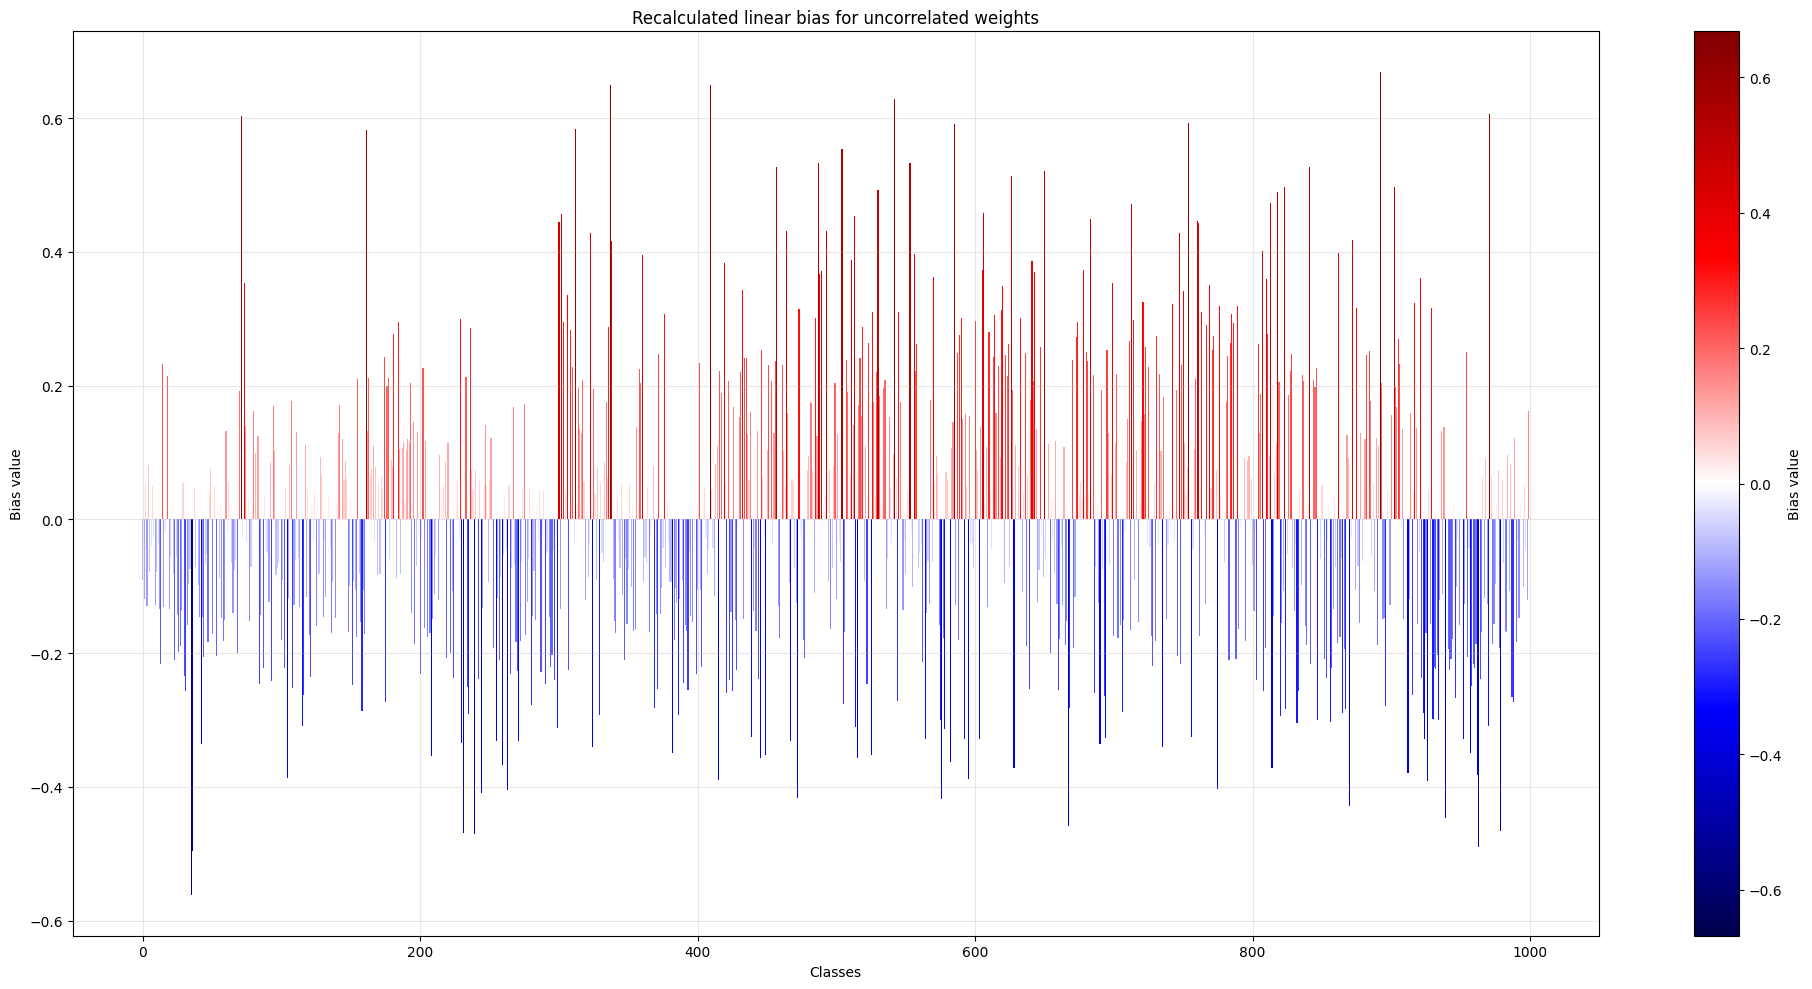

In [49]:
logits_orig = activn_sample @ weights_orig.T + bias_orig
logits_unbiased = activn_sample @ weights_uncorr.T
bias_uncorr = np.mean(logits_orig - logits_unbiased, axis=0)

plot_colored_barplot(
    values=bias_uncorr,
    values_color=bias_uncorr,
    values_color_name="Bias value",
    title="Recalculated linear bias for uncorrelated weights",
    xlabel="Classes",
    ylabel="Bias value",
    edge_color=None,
    figsize=(20,10)
)

In [50]:
regnetx_3_2.fc.weight.data = torch.from_numpy(weights_uncorr).float().to(device)
regnetx_3_2.fc.bias.data = torch.from_numpy(bias_uncorr).float().to(device)

In [ ]:
print("\n[ ] Validating model after linear layer replacement:")
top1_uncorr, top5_uncorr, val_time, _, _ = pretty_print_top1_top5_time(
    regnetx_3_2, val_loader,
    top1_orig=top1_orig,
    top5_orig=top5_orig
)


[ ] Validating model after linear layer replacement:
    Top-1 Accuracy:  0.9360, drop: 80.0540
    Top-5 Accuracy:  3.0340, drop: 92.3700
    Validation time: 765.8883 s


## Codebook extraction experiments

### Extractor class definition

In [ ]:
class BoostingCodebookExtractor:
    def __init__(self, 
                 max_codewords_per_class,
                 divergence_type: str | None  = "KL",
                 is_refinement: bool | None  = True,
                 refinement_radius: int | None  = 1,
                 div_limit: float | None  = 1e-4,
                 max_iter: int | None  = 100,
                 random_state: int | None  = None):
        """
        Parameters:
            max_codewords_per_class : Maximum code words number per class
            divergence_type :         Divergence type in {'KL', 'L2'}
            is_refinement :           Whether to use codewords local refinement or not
            refinement_radius :       Hamming radius for codeword refinement
            div_limit :               Divergence limit, sufficient for early-stopping
            max_iter :                Maximum iterations number
            random_state :            Random state for experiment reproducibility
        """
        assert divergence_type in ["KL", "L2"], "Only divergence types {'KL', 'L2'} are supported"

        self.max_codewords_per_class = max_codewords_per_class
        self.divergence_type = divergence_type
        self.is_refinement = is_refinement
        self.refinement_radius = refinement_radius
        self.div_limit = div_limit
        self.max_iter = max_iter
        self.random_state = random_state
        
        self.codebooks_ = [[]]
        self.lambda_ = 0
        self.betas_ = []
        self.n_features_ = 0
        self.n_classes_ = 0
        
        if random_state is not None:
            np.random.seed(random_state)
    
    def _hamming_distance(self, 
                          X: np.ndarray, 
                          codeword: np.ndarray) -> np.ndarray:
        """
        Compute Hamming distance between soft-binary vectors and binary codeword
        
        Parameters:
            X :        Soft-binary vectors, shape (n_samples, n_features)
            codeword : Binary codeword,     shape (n_features,)
            
        Returns:
            distances : Hamming distance,   shape (n_samples,)
        """
        return np.sum(X * (1 - codeword) + (1 - X) * codeword, axis=1)
    
    def compute_student_logits(self, X: np.ndarray) -> np.ndarray:
        """
        Compute student logits for all classes
        
        Parameters:
            X : Soft-binary vectors,   shape (n_samples, n_features)
            
        Returns:
            s_logits : Student logits, shape (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        s_logits = np.zeros((n_samples, self.n_classes_))
        
        for class_idx in range(self.n_classes_):
            if not self.codebooks_[class_idx]:    # for no codewords large distance is used
                min_dists = np.full(n_samples, self.n_features_)
            else:                                 # calculate distance to all codewords of the class
                dists = np.column_stack([
                    self._hamming_distance(X, codeword) 
                    for codeword in self.codebooks_[class_idx]
                ])
                min_dists = np.min(dists, axis=1)
            
            # s_y(x) = -lambda * min_{c \in C(y)} d_H(x,c) + beta_y
            s_logits[:, class_idx] = -self.lambda_ * min_dists + self.betas_[class_idx]
        
        return s_logits
    
    def _compute_divergence(self, 
                            t_logits: np.ndarray, 
                            s_logits: np.ndarray,
                            epsilon: float | None  = 1e-12) -> np.ndarray:
        """
        Compute divergence between teacher & student logits
        
        Parameters:
            t_logits : Teacher logits, shape (n_samples, n_classes)
            s_logits : Student logits, shape (n_samples, n_classes)
            epsilon :  Zero logarithm protection for numerical stability
            
        Returns:
            divergence : Divergence between logits of specified type, shape (n_samples,)
        """
        if self.divergence_type == 'L2':
            return np.linalg.norm(t_logits - s_logits, axis=1)
        
        else:  # KL( \sigma(t) || \sigma(s) )
            t_probs = np.clip(softmax(t_logits, axis=1), epsilon, 1.0)
            s_probs = np.clip(softmax(s_logits, axis=1), epsilon, 1.0)
            return np.sum(t_probs * (np.log(t_probs) - np.log(s_probs)), axis=1)
    
    
    def _initialize_codebooks(self, 
                              X: np.ndarray, 
                              y: np.ndarray, 
                              W: np.ndarray | None ) -> None:
        """
        Codebooks initialization
        
        Parameters:
            X : Soft-binary features,           shape (n_samples, n_features)
            y : Classes labels vector,          shape (n_samples,)
            W : fc.weights for bit calibration, shape (n_classes, n_features)
        """
        n_samples, n_features = X.shape
        
        if W is not None:
            s = np.sign(np.sum(W, axis=0))
            for j in range(n_features):
                if s[j] < 0:
                    X[:, j] = 1 - X[:, j]
        
        self.codebooks_ = [[] for _ in range(self.n_classes_)]
        
        for class_idx in range(self.n_classes_):
            class_mask = (y == class_idx)
            if np.sum(class_mask):
                mean_bits = np.mean(X[class_mask], axis=0)
                self.codebooks_[class_idx].append(
                    (mean_bits >= 0.5).astype(np.float64)
                )
            else:
                self.codebooks_[class_idx].append(
                    np.random.randint(0, 2, n_features).astype(np.float64)
                )

        self._calibrate_parameters(X, y)
    
    def _calibrate_parameters(self, 
                              X: np.ndarray, 
                              y: np.ndarray, 
                              t_logits: np.ndarray | None ) -> None:
        """
        Lambda & betas calibration
        
        Parameters:
            X :        Soft-binary features, shape (n_samples, n_features)
            y :        Classes labels,       shape (n_samples,)
            t_logits : Teacher's logits. When `None`, `t_logits` from `fit` is used 
                                             shape (n_samples, n_classes)
        """
        n_samples = X.shape[0]
        
        distances = np.zeros(n_samples)
        for i in range(n_samples):
            class_idx = y[i]
            if self.codebooks_[class_idx]:
                dists = [
                    self._hamming_distance(X[i:i+1], c)[0] 
                    for c in self.codebooks_[class_idx]
                ]
                distances[i] = np.min(dists)
            else:
                distances[i] = self.n_features_
        
        if t_logits is None:
            t_logits = self.t_logits_
        t_target = t_logits[np.arange(n_samples), y]
        
        # Linear regression: t_i \approx \alpha + \beta * d_i
        slope, intercept, r_value, p_value, std_err, intercept_err = stats.linregress(distances, t_target)
        
        self.lambda_ = -slope
        self.betas_ = np.full(self.n_classes_, intercept)
    
    def _refine_codeword(self, 
                         X_class: np.ndarray, 
                         prototype: np.ndarray, 
                         radius: int) -> np.ndarray:
        """
        Refine codeword via majority vote over neighbors
        
        Parameters:
            X_class :   Same class samples, shape (n_class_samples, n_features)
            prototype : Prototype codeword, shape (n_features,)
            radius :    Hamming radius to find neighbors
            
        Returns:
            refined_codeword : Refined codeword, shape (n_features,)
        """
        neighbors = X_class[
            np.sum(
                (X_class >= 0.5).astype(int) != (prototype >= 0.5).astype(int), 
                axis=1
            ) <= radius
        ]
        return (np.mean(neighbors, axis=0) >= 0.5).astype(np.float64) \
            if len(neighbors) else \
            prototype.copy()
    
    def _reassign_and_refine(self, 
                             X: np.ndarray, 
                             y: np.ndarray) -> None:
        """
        Subclasses reassignation & codewords local finetuning
        
        Parameters:
            X : Soft-binary features, shape (n_samples, n_features)
            y : Classes labels,       shape (n_samples,)
        """
        for class_idx in range(self.n_classes_):
            if not self.codebooks_[class_idx]:
                continue
                
            X_class = X[y == class_idx]
            if not len(X_class):
                continue
            
            # find closest codeword for every sample
            assignments = []
            for x in X_class:
                dists = [
                    self._hamming_distance(x.reshape(1, -1), c)[0] 
                    for c in self.codebooks_[class_idx]
                ]
                assignments.append(np.argmin(dists))
            assignments = np.array(assignments)
            
            # update codewords as centers of the assigned clusters
            for codeword_i in range(len(self.codebooks_[class_idx])):
                cluster_mask = (assignments == codeword_i)
                if np.sum(cluster_mask) > 0:
                    cluster_samples = X_class[cluster_mask]
                    mean_bits = np.mean(cluster_samples, axis=0)
                    new_codeword = (mean_bits >= 0.5).astype(np.float64)
                    self.codebooks_[class_idx][codeword_i] = new_codeword
    
    
    def fit(self, 
            X: np.ndarray, 
            y: np.ndarray, 
            t_logits: np.ndarray,
            W: np.ndarray | None ) -> 'BoostingCodebookExtractor':
        """
        Codebook extraction algorithm training
        
        Parameters:
            X :        Soft-binary features in [0,1]^n_features, shape (n_samples, n_features)
            y :        True labels in {0, 1, ..., C-1},          shape (n_samples,)
            t_logits : Teacher's logits,                         shape (n_samples, n_classes)
            W :        fc.weights for bit calibration,           shape (n_classes, n_features)
            
        Returns:
            BoostingCodebookExtractor : Trained boosting codebook extractor
        """
        n_samples, n_features = X.shape
        self.n_features_ = n_features
        self.n_classes_ = len(np.unique(y))
        self.t_logits_ = t_logits
        
        assert X.shape[0] == y.shape[0] == t_logits.shape[0], "`n_samples` are different for different objects"
        assert t_logits.shape[1] == self.n_classes_, "Classes number differs"
        if W is not None:
            assert W.shape[0] == self.n_classes_ and W.shape[1] == n_features, "Wrong shape of `W`"
        
        self._initialize_codebooks(X, y, W)
        
        for iter in range(self.max_iter):
            s_logits = self.compute_student_logits(X)
            divergences = self._compute_divergence(t_logits, s_logits)
            
            mean_divergence = np.mean(divergences)
            print("MIN, MEAN, MAX OF DIVERGENCES: ", min(divergences), mean_divergence, max(divergences))
            if mean_divergence < self.div_limit:
                print(f"EARLY STOP! Achieved mean divergence: {mean_divergence:.6f} - "
                      f"on iteration {iter}")
                break
            
            i_maxdiv = np.argmax(divergences)
            y_maxdiv = y[i_maxdiv]
            
            if len(self.codebooks_[y_maxdiv]) >= self.max_codewords_per_class:
                if not iter:
                    raise ValueError("Impossible to add a codeword: "
                                     f"reached maximum codewords number for class {y_maxdiv}")
                else:
                    print(f"Reached maximum codewords number for class {y_maxdiv}")
                    break
            
            prototype = (X[i_maxdiv] >= 0.5).astype(np.float64)
            
            X_class = X[y == y_maxdiv]
            refined_codeword = self._refine_codeword(X_class, prototype, self.refinement_radius) \
                if (self.is_refinement and len(X_class)) else \
                    prototype
            
            self.codebooks_[y_maxdiv].append(refined_codeword)
            self._reassign_and_refine(X, y)
            self._calibrate_parameters(X, y, t_logits)
            
            if not iter % 10:
                print(f"Iteration {iter}, mean divergence: {mean_divergence:.6f}")
        
        return self
    
    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Class prediction for new samples
        
        Parameters:
            X : Soft-binary features,        shape (n_samples, n_features)

        Returns:
            predictions : Predicted classes, shape (n_samples,)
        """
        return np.argmax(self.compute_student_logits(X), axis=1)
    
    
    def get_codebooks(self) -> list[list[np.ndarray]]:
        """        
        Returns:
            codebooks : Binary codebooks for every class
        """
        return self.codebooks_
    
    def get_parameters(self) -> tuple[float, np.ndarray]:
        """        
        Returns:
            lambda : Global scale
            betas :  Bias for every class, shape (n_classes,)
        """
        return self.lambda_, self.betas_

### Extractor usage

In [ ]:
random_seed = 42

val_loader_len = len(val_loader.dataset) # 32000
n_features = weights_uncorr.shape[1]
max_codewords_per_class = val_loader_len // n_classes
divergence_type = "KL"

print(f"Training extractor on {val_loader_len} training samples "
      "with maximum number of codewords per class:", 
      max_codewords_per_class)

Training extractor on 50000 training samples with maximum number of codewords per class: 50


In [ ]:
print("[ ] Getting training data for codebook extractor...")

soft_bin_features = np.zeros((val_loader_len, n_features), dtype=np.float32)
targets = np.zeros(val_loader_len, dtype=np.float32)
t_logits = np.zeros((val_loader_len, n_classes), dtype=np.float32)

start_filling = 0

with torch.no_grad():
    for i, (images_batch, targets_batch) in enumerate(val_loader):
        print(f"Processing batch {i}...")
        
        images_batch = images_batch.to(device, non_blocking=True)
        targets_batch = targets_batch.to(device, non_blocking=True)

        t_logits_batch = regnetx_3_2(images_batch)
        print("    Got logits of shape:", t_logits_batch.shape)
        print("    Avgpool input binarized into values:", avgpool_input_bin_values.data)
        
        print("avgpool_input_bin.shape:", avgpool_input_bin.shape, "avgpool_input_float.shape", avgpool_input_float.shape)
        
        end_filling = min(start_filling + batch_size, val_loader_len)
        soft_bin_features[ start_filling : end_filling ] = avgpool_input_bin.cpu().numpy()
        targets[ start_filling : end_filling ] = targets_batch.cpu().numpy()
        t_logits[ start_filling : end_filling ] = t_logits_batch.cpu().numpy()
        
        start_filling = end_filling
        

print("[V] Training data for codebook extractor prepared with:\n"
      f"    soft binary feature matrix shape:  {soft_bin_features.shape},\n" # [val_loader_len, n_classes]
      f"    target vector shape:               {targets.shape},\n"           # [val_loader_len]
      f"    teacher model logits matrix shape: {t_logits.shape}")            # [val_loader_len, n_classes]

[ ] Getting training data for codebook extractor...
Processing batch 0...
    Got logits of shape: torch.Size([32, 1000])
    Avgpool input binarized into values: tensor([ 0., 63.], device='cuda:0')
avgpool_input_bin.shape: torch.Size([32, 1008, 7, 7]) avgpool_input_float.shape torch.Size([32, 1008, 7, 7])


ValueError: could not broadcast input array from shape (32,1008,7,7) into shape (32,1000)

In [ ]:
print("[ ] Initializing codebook extractor...")
codebook_extractor = BoostingCodebookExtractor(
    max_codewords_per_class=max_codewords_per_class,
    divergence_type=divergence_type,
    is_refinement=True,
    refinement_radius=2,
    div_limit=1e-4,
    max_iter=50,
    random_state=random_seed
)
print("[V] Codebook extractor ready for training")

In [ ]:
# TODO: add these tensors for ResNetX_3_2, ImageNet
soft_bin_features = np.load("tensors_for_experiments/soft_bin_features.npy")
targets = np.load("tensors_for_experiments/targets.npy")
t_logits = np.load("tensors_for_experiments/t_logits.npy")

In [ ]:
print("[ ] Codebook extractor training...")
codebook_extractor.fit(
    soft_bin_features, 
    targets, 
    t_logits, 
    weights_uncorr
)
print("[V] Codebook extractor training finished")

In [ ]:
predictions = codebook_extractor.predict(soft_bin_features)
codebooks = codebook_extractor.get_codebooks()
lambdas, betas = codebook_extractor.get_parameters()

print("Codebook parameters extracted:"
      "\n    Predictions:\n", predictions,
      "\n    Codebooks:\n",   codebooks,
      "\n    Lambdas:\n",     lambdas,
      "\n    Betas:\n",       betas)